# Imbalanced Learning 
### `Does the variance-reduction of parallel ensembles offer better generalization on noisy sensor data compared to the bias-reduction of sequential ensembles?`

The goal of this section is to manage the class imbalance in our air quality dataset, where some categories are less represented (like Hazardous at 10%). 

First, we want to `have a look at the imbalance distribution` we are going to deal with. Then, we are going to `compare standard ensembles` like Random Forest with specialized methods as `Balanced Random Forest` or `RUSBoost`, once it's done, we will try a parallel approach to data resampling with algorithmic modification via `cost-sensitive learning`, 

and finally `test robustness to missing sensor data.`

## 0. Initial Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, recall_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.ensemble import BalancedRandomForestClassifier, RUSBoostClassifier
from imblearn.combine import SMOTEENN
import xgboost as xgb
from sklearn.impute import KNNImputer, SimpleImputer

In [61]:
# This peace of code comes from the EDA of the 00_baselines notebook
data = pd.read_csv("../data/updated_pollution_dataset.csv")

target_col = data.columns[-1]

quality_map = {
    "Good": 3,
    "Moderate": 2,
    "Poor": 1,
    "Hazardous": 0
}

data[target_col] = data[target_col].map(quality_map)
data[target_col] = data[target_col].astype("int8")

# 1. Class Imbalance Analysis

Before training and testing these models, we want to have a quick view of our dataset classes distribution. 

The categories are `Good, Moderate, Poor and Hazardous`.

Class distribution of Air Quality
3    2000
2    1500
1    1000
0     500
Name: count, dtype: int64
Class percentage distribution of Air Quality
3    40.0
2    30.0
1    20.0
0    10.0
Name: count, dtype: float64


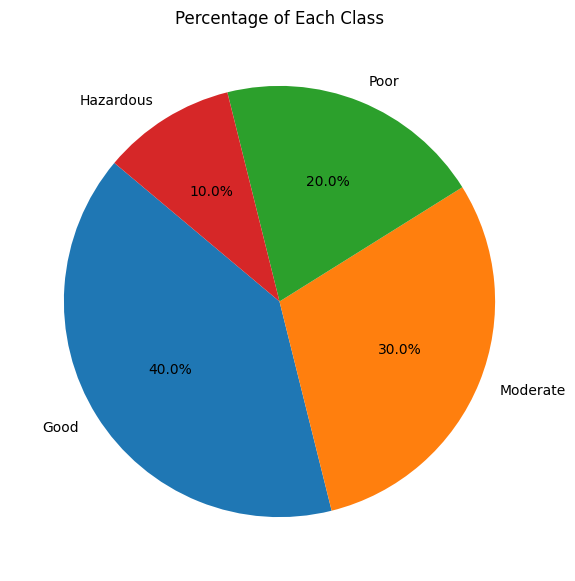

In [62]:
class_counts = data[target_col].value_counts()
print("Class distribution of", class_counts)
class_percentages = (class_counts / class_counts.sum()) * 100
print("Class percentage distribution of", class_percentages)

label_map = {0: "Hazardous", 1: "Poor", 2: "Moderate", 3: "Good"}
labels = [label_map[i] for i in class_percentages.index]

plt.figure(figsize=(10, 7))
plt.pie(class_percentages, labels=labels, autopct="%1.1f%%", startangle=140)
plt.title("Percentage of Each Class")
plt.show()

These results shows a big imbalance, being `Good 40% and Moderate 30%` the most predominant categories. This leaves `Poor with 20% and Hazardous at 10%`. 

Having in mind that the most important category to always predict correctly is `Hazardous`, it's vital for us to build a model able to precisely detect when air quality is not safe for our health.

So, having that this distribution could generate a bias in our models, it motivates us to try different approaches beyond simple oversampling or undersampling. 


In [ ]:
# Train test split
X, y = data.drop(columns=data.columns[-1]), data[data.columns[-1]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4000, 9), Test: (1000, 9)


## 2. Standard Ensembles vs Imbalanced-Specialized Ensembles

The main goal of this step is to `know if ensemble variants made to deal with class imbalance outperform standard methods on minority class detection` (mainly "Hazardous" in this case).

We are going to train and compare 4 approaches:

- Random Forest (baseline)

- AdaBoost (adaptive boosting)

- Balanced Random Forest (imbalanced-learn undersampling at each split)

- RUSBoost (Random Undersampling + AdaBoost)

- SMOTENN-Boost (SMOTE oversampling + Edited Nearest Neighbors undersampling (ENN) + Adaboost)

We expect models designed to handle unbalanced data to do a better job at correctly detecting the "Hazardous" cases, without hurting overall accuracy too much.

In [ ]:
# We are going to reuse the best hyperparameters found with GridSearch in the 01_ensemble_learning notebook
best_ada_params = { "estimator": DecisionTreeClassifier(max_depth=4, min_samples_leaf=2), 
                   "n_estimators": 250, "learning_rate": 0.1, "random_state": 42}

models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(**best_ada_params),
    "Balanced Random Forest": BalancedRandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "RUSBoost": RUSBoostClassifier(n_estimators=200, random_state=42)}

results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    results[name] = {
        "F1 macro": round(f1_score(y_test, y_pred, average="macro"), 4),
        "Hazardous recall": round(recall_score(y_test, y_pred, labels=[0], average="macro"), 4)}
    print("\n",name,"\n", classification_report(y_test, y_pred, target_names=["Hazardous", "Poor", "Moderate", "Good"]))

# SMOTENN (SMOTE + ENN) oversampling with SMOTE, undersampling with Edited Nearest Neighbors
# SMOTE-Boost: SMOTE before fitting AdaBoost

smote_enn = SMOTEENN(random_state=42)
X_train_sm, y_train_sm = smote_enn.fit_resample(X_train_sc, y_train)

smote_boost = AdaBoostClassifier(n_estimators=100, random_state=42)
smote_boost.fit(X_train_sm, y_train_sm)
y_pred_sb = smote_boost.predict(X_test_sc)

results["SMOTE-Boost"] = {
    "F1 macro": round(f1_score(y_test, y_pred_sb, average="macro"), 4),
    "Hazardous recall": round(recall_score(y_test, y_pred_sb, labels=[0], average="macro"), 4)}

print("\nSMOTE-Boost")
print(classification_report(y_test, y_pred_sb, target_names=["Hazardous", "Poor", "Moderate", "Good"]))

# Summary table
print("\nSummary")
print(pd.DataFrame(results).T.sort_values("Hazardous recall", ascending=False))


 Random Forest 
               precision    recall  f1-score   support

   Hazardous       0.92      0.88      0.90       111
        Poor       0.88      0.90      0.89       186
    Moderate       0.97      0.97      0.97       294
        Good       1.00      1.00      1.00       409

    accuracy                           0.96      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.96      0.96      0.96      1000


 AdaBoost 
               precision    recall  f1-score   support

   Hazardous       0.92      0.86      0.89       111
        Poor       0.86      0.92      0.89       186
    Moderate       0.98      0.96      0.97       294
        Good       1.00      1.00      1.00       409

    accuracy                           0.96      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.96      0.96      0.96      1000


 Balanced Random Forest 
               precision    recall  f1-score   support

   Hazardous     

These results mean that `BalancedRF does especially well at catching the Hazardous cases while still performing as well as the other models` overall, making it a great fit for our case where precise Hazardous detections matter most. 

`RUSBoost doesn’t perform as well,` probably because it throws away too much data when trying to balance categories. 

`AdaBoost and Random Forest perform similarly,` they have a good performance across all categories, with high overall accuracy and Hazardous recall, even though they don’t prioritize the minority class as much as BalancedRF. Also, Adaboost has with a slight drop in Hazardous recall, suggesting it’s a bit less effective on those extreme cases.

`SMOTENN-Boost struggles significantly,` boosting recall for some classes but at the cost of very poor performance on the majority class (Good), leading to much lower overall accuracy.

## 3. Cost-Sensitive Learning with penalty matrix

At this step, we want to build a misclassification cost matrix (for example predicting Good for Hazardous cases costs most). We will use these penalties to give more importance to risky cases when training the Random Forest.

By penalizing dangerous mistakes, the model should improve its ability to detect Hazardous cases, even if that slightly affects performance on the more common classes.

In [ ]:
# The idea is that predicting Hazardous as Good is worse than predicting it as Poor.

penalty_matrix = np.array([
    [0, 1, 4, 9],  # true=Hazardous(0) predicted as 0,1,2,3
    [1, 0, 1, 4],  # true=Poor(1)
    [4, 1, 0, 1],  # true=Moderate(2)
    [9, 4, 1, 0]]) # true=Good(3)

# We translate the penalty matrix into sample weights for each training sample
# based on what class it belongs to, heavier weight for dangerous classes

def get_sample_weights(y_train, penalty_matrix):
    # Weight for each sample = average penalty of misclassifying that class
    weights = np.array([penalty_matrix[cls].mean() for cls in y_train])
    return weights

sample_weights = get_sample_weights(y_train, penalty_matrix)

rf_cost = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_cost.fit(X_train_sc, y_train, sample_weight=sample_weights)
y_pred_cost = rf_cost.predict(X_test_sc)

print("Cost-Sensitive Random Forest")
print("F1 macro: ", round(f1_score(y_test, y_pred_cost, average="macro"), 4))
print("Hazardous recall:", round(recall_score(y_test, y_pred_cost, labels=[0], average="macro"), 4))
print(classification_report(y_test, y_pred_cost, target_names=["Hazardous", "Poor", "Moderate", "Good"]))

# Compare with standard RF
print("Standard Random Forest (for reference)")
rf_base = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_base.fit(X_train_sc, y_train)
y_pred_base = rf_base.predict(X_test_sc)
print("F1 macro: ", round(f1_score(y_test, y_pred_base, average="macro"), 4))
print("Hazardous recall:", round(recall_score(y_test, y_pred_base, labels=[0], average="macro"), 4))

Cost-Sensitive Random Forest
F1 macro:  0.9342
Hazardous recall: 0.8468
              precision    recall  f1-score   support

   Hazardous       0.91      0.85      0.88       111
        Poor       0.87      0.91      0.89       186
    Moderate       0.97      0.97      0.97       294
        Good       1.00      1.00      1.00       409

    accuracy                           0.96      1000
   macro avg       0.94      0.93      0.93      1000
weighted avg       0.96      0.96      0.96      1000

Standard Random Forest (for reference)
F1 macro:  0.9383
Hazardous recall: 0.8829


The cost-sensitive Random Forest achieves strong overall performance, but `its Hazardous recall is still lower than BalancedRF`. While the penalty system helps highlight critical cases, `it doesn’t close the gap`, meaning that better tuning of the weights could improve results.

## 4. Robustness to Missing Data

Our last approach is trying to simulate real world sensor failures `by randomly removing 10,20 and 30% of PM2.5 and NO2`. 

We then compare how Random Forest performs with KNN or mean imputation versus XGBoost (our best model of the ensemble learning notebook), which can natively handle missing values.

We think that XGBoost, as we already discovered before, `should maintain a good performance, even better than imputation pipelines`, but we want to test how it specifically performs under heavy data dropouts. 

In [ ]:
# We simulate sensor failure by randomly dropping PM2.5 and NO2 values
# This function simulates randomly replaces values of PM2.5 and NO2 readings with null.

dropout_rates = [0.1, 0.2, 0.3] # 10%, 20% and 30%
sensor_cols   = ["PM2.5", "NO2"]

def simulate_dropout(X, cols, rate, random_state=42):
    X_missing = X.copy()
    rng = np.random.default_rng(random_state)
    for col in cols:
        if col in X_missing.columns:
            mask = rng.random(len(X_missing)) < rate
            X_missing.loc[mask, col] = np.nan
    return X_missing


In [ ]:
# compare imputation strategies vs XGBoost with NaN handling

results_missing = []

for rate in dropout_rates:
    X_test_missing = simulate_dropout(X_test, sensor_cols, rate)

    # KNN Imputation + Random Forest
    knn_imputer = KNNImputer(n_neighbors=5)
    X_train_imp = knn_imputer.fit_transform(X_train)
    X_test_imp  = knn_imputer.transform(X_test_missing)

    sc2 = StandardScaler()
    X_train_imp_sc = sc2.fit_transform(X_train_imp)
    X_test_imp_sc  = sc2.transform(X_test_imp)

    rf_knn = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf_knn.fit(X_train_imp_sc, y_train)
    y_pred_knn = rf_knn.predict(X_test_imp_sc)

    # Mean Imputation + Random Forest
    mean_imputer = SimpleImputer(strategy="mean")
    X_train_mean = mean_imputer.fit_transform(X_train)
    X_test_mean  = mean_imputer.transform(X_test_missing)

    sc3 = StandardScaler()
    X_train_mean_sc = sc3.fit_transform(X_train_mean)
    X_test_mean_sc  = sc3.transform(X_test_mean)

    rf_mean = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf_mean.fit(X_train_mean_sc, y_train)
    y_pred_mean = rf_mean.predict(X_test_mean_sc)

    # XGBoost
    xgb_model = xgb.XGBClassifier(n_estimators=300, random_state=42,
                                   use_label_encoder=False, eval_metric="mlogloss")
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test_missing)

    results_missing.append({
        "Dropout rate": rate,
        "RF + KNN impute F1": round(f1_score(y_test, y_pred_knn,  average="macro"), 4),
        "RF + Mean impute F1": round(f1_score(y_test, y_pred_mean, average="macro"), 4),
        "XGBoost F1": round(f1_score(y_test, y_pred_xgb,  average="macro"), 4),
        "RF + KNN Haz recall": round(recall_score(y_test, y_pred_knn,  labels=[0], average="macro"), 4),
        "RF + Mean Haz recall": round(recall_score(y_test, y_pred_mean, labels=[0], average="macro"), 4),
        "XGBoost Haz recall": round(recall_score(y_test, y_pred_xgb,  labels=[0], average="macro"), 4)})

print("Robustness to Missing Data")
print(pd.DataFrame(results_missing).to_string(index=False))

Robustness to Missing Data
 Dropout rate  RF + KNN impute F1  RF + Mean impute F1  XGBoost F1  RF + KNN Haz recall  RF + Mean Haz recall  XGBoost Haz recall
          0.1              0.9344               0.9345      0.9349               0.8739                0.8559              0.9099
          0.2              0.9326               0.9325      0.9213               0.8649                0.8378              0.9279
          0.3              0.9289               0.9288      0.9084               0.8559                0.8108              0.9369


`XGBoost consistently outperforms the imputation-based Random Forest pipelines under ALL dropout cases`. 

`Even with 30% missing data, it keeps Hazardous recall above 90%`, making it highly robust for deployments tendent to sensor failures. `Random Forest with KNN or mean imputation losses performace gradually`, with mean imputation showing the biggest drop in detecting critical Hazardous cases.

## 5. Final Conclussion

This analysis evaluated multiple strategies for detecting air quality categories under an imbalanced dataset, with a special interest on predicting critical Hazardous cases while maintaining strong performance with the rest.

`Base models` (Random Forest, AdaBoost) `achieved high overall accuracy and macro F1 scores, but were limited in detecting minority Hazardous events` compared to other approaches.

`Balanced Random Forest` substantially improved Hazardous recall without loosing precision with the other categories, making it `the best choice for the "Hazardous" category detection.`

`Cost-sensitive Random Forest` made a good use of our severity mistake based penalties, boosting Hazardous detection, although it still remained behind BalancedRF.

`Imbalanced-data approaches` (RUSBoost, SMOTENN-Boost) showed mixed results: aggressive undersampling in RUSBoost reduced overall performance, while SMOTE-Boost struggled to maintain majority-class accuracy.

Robustness to missing data demonstrates the capacity of XGBoost’s  NaNs handling ability. Even with 30% sensor dropout, XGBoost maintained Hazardous recall above 90%, doing better than imputation based Random Forest pipelines.


`BalancedRF and XGBoost stand out as complementary solutions.` BalancedRF is great at handling class imbalance and detecting Hazardous cases, while XGBoost ensures robustness under realistic sensor failures. Together, these models provide a reliable performance for real world air quality monitoring systems where both rare events detection and being able to work even with missing data are vital.